In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

In [34]:
class LinearRegressor:
  def __init__(self,lr=0.05,n_iters=1000):
    self.lr=lr
    self.n_iters=n_iters
    self.weights=None
    self.bias=None

  def fit(self,X,Y):
    samples,features=X.shape
    self.weights=np.zeros(features)
    self.bias=0
    for _ in range(self.n_iters):
      y_pred=np.dot(self.weights,X.T)+self.bias
      dw=(1/self.n_iters)*np.dot(X.T,(y_pred-Y))
      db=(1/self.n_iters)*np.sum(y_pred-Y)

      self.weights=self.weights-dw*self.lr
      self.bias=self.bias-db*self.lr

  def predict(self,X):
    return np.dot(self.weights,X.T)+self.bias

In [35]:
X,Y=make_regression(n_samples=100,n_features=1,noise=20,random_state=4)

In [36]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=20,random_state=42)

In [37]:
linear_regression=LinearRegressor()

In [38]:
linear_regression.fit(X_train,Y_train)

In [39]:
y_pred=linear_regression.predict(X_test)

In [40]:
y_pred

array([  58.8397303 ,  -46.61115507,   58.74641569, -105.602475  ,
         85.6870463 ,   14.45397376,  -83.79037495,   58.11613987,
        -46.61569935,  -97.71101524,   22.61745183,   22.3761727 ,
         12.35443834,   15.96307865,  -72.04107964,    4.1845822 ,
          4.37117937,  -37.88914547, -115.02506149, -111.98395193])

In [41]:
def calculate_mse(y_pred,y):
  return np.mean((y_pred-y)**2)

In [42]:
mse=calculate_mse(y_pred,Y_test)

In [43]:
mse

np.float64(336.4242160715901)

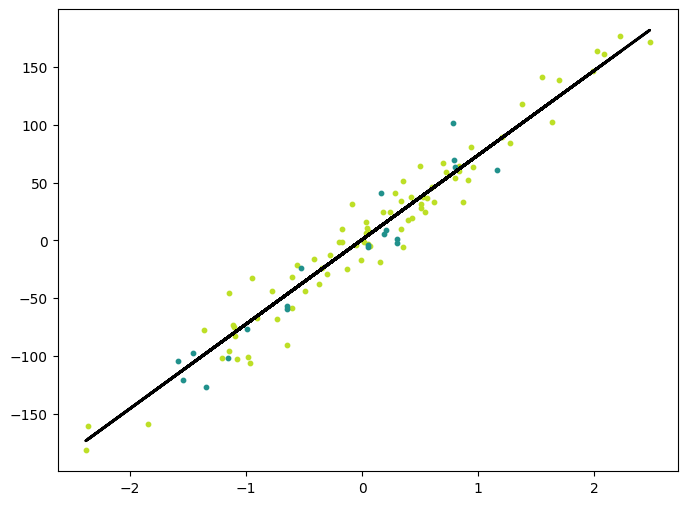

In [44]:
cmap=plt.get_cmap('viridis')
fig=plt.figure(figsize=(8,6))
m1=plt.scatter(X_train,Y_train,color=cmap(0.9),s=10)
m2=plt.scatter(X_test,Y_test,color=cmap(0.5),s=10)
plt.plot(X,linear_regression.predict(X),color='black',linewidth=2,label='Prediction')
plt.show()